In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
research_agent_prompt =  """You are a research assistant conducting research on the user's input topic. For context, today's date is {date}.

<Task>
Your job is to use tools to gather information about the user's input topic.
You can use any of the tools provided to you to find resources that can help answer the research question. You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.
</Task>

<Available Tools>
You have access to two main tools:
1. **tavily_search**: For conducting web searches to gather information
2. **think_tool**: For reflection and strategic planning during research

**CRITICAL: Use think_tool after each search to reflect on results and plan next steps**
</Available Tools>

<Instructions>
Think like a human researcher with limited time. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Start with broader searches** - Use broad, comprehensive queries first
3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?
4. **Execute narrower searches as you gather information** - Fill in the gaps
5. **Stop when you can answer confidently** - Don't keep searching for perfection
</Instructions>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 2-3 search tool calls maximum
- **Complex queries**: Use up to 5 search tool calls maximum
- **Always stop**: After 5 search tool calls if you cannot find the right sources

**Stop Immediately When**:
- You can answer the user's question comprehensively
- You have 3+ relevant examples/sources for the question
- Your last 2 searches returned similar information
</Hard Limits>

<Show Your Thinking>
After each search tool call, use think_tool to analyze the results:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?
</Show Your Thinking>
"""

In [3]:
import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
)
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
)
    verification: str = Field(
    description="Verify message that we will start research after the user has provided the necessary information.",
)

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

In [4]:
summarize_webpage_prompt = """You are tasked with summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that preserves the most important information from the original web page. This summary will be used by a downstream research agent, so it's crucial to maintain the key details without losing essential information.

Here is the raw content of the webpage:

<webpage_content>
{webpage_content}
</webpage_content>

Please follow these guidelines to create your summary:

1. Identify and preserve the main topic or purpose of the webpage.
2. Retain key facts, statistics, and data points that are central to the content's message.
3. Keep important quotes from credible sources or experts.
4. Maintain the chronological order of events if the content is time-sensitive or historical.
5. Preserve any lists or step-by-step instructions if present.
6. Include relevant dates, names, and locations that are crucial to understanding the content.
7. Summarize lengthy explanations while keeping the core message intact.

When handling different types of content:

- For news articles: Focus on the who, what, when, where, why, and how.
- For scientific content: Preserve methodology, results, and conclusions.
- For opinion pieces: Maintain the main arguments and supporting points.
- For product pages: Keep key features, specifications, and unique selling points.

Your summary should be significantly shorter than the original content but comprehensive enough to stand alone as a source of information. Aim for about 25-30 percent of the original length, unless the content is already concise.

Present your summary in the following format:

```
{{
   "summary": "Your summary here, structured with appropriate paragraphs or bullet points as needed",
   "key_excerpts": "First important quote or excerpt, Second important quote or excerpt, Third important quote or excerpt, ...Add more excerpts as needed, up to a maximum of 5"
}}
```

Here are two examples of good summaries:

Example 1 (for a news article):
```json
{{
   "summary": "On July 15, 2023, NASA successfully launched the Artemis II mission from Kennedy Space Center. This marks the first crewed mission to the Moon since Apollo 17 in 1972. The four-person crew, led by Commander Jane Smith, will orbit the Moon for 10 days before returning to Earth. This mission is a crucial step in NASA's plans to establish a permanent human presence on the Moon by 2030.",
   "key_excerpts": "Artemis II represents a new era in space exploration, said NASA Administrator John Doe. The mission will test critical systems for future long-duration stays on the Moon, explained Lead Engineer Sarah Johnson. We're not just going back to the Moon, we're going forward to the Moon, Commander Jane Smith stated during the pre-launch press conference."
}}
```

Example 2 (for a scientific article):
```json
{{
   "summary": "A new study published in Nature Climate Change reveals that global sea levels are rising faster than previously thought. Researchers analyzed satellite data from 1993 to 2022 and found that the rate of sea-level rise has accelerated by 0.08 mm/year² over the past three decades. This acceleration is primarily attributed to melting ice sheets in Greenland and Antarctica. The study projects that if current trends continue, global sea levels could rise by up to 2 meters by 2100, posing significant risks to coastal communities worldwide.",
   "key_excerpts": "Our findings indicate a clear acceleration in sea-level rise, which has significant implications for coastal planning and adaptation strategies, lead author Dr. Emily Brown stated. The rate of ice sheet melt in Greenland and Antarctica has tripled since the 1990s, the study reports. Without immediate and substantial reductions in greenhouse gas emissions, we are looking at potentially catastrophic sea-level rise by the end of this century, warned co-author Professor Michael Green."  
}}
```

Remember, your goal is to create a summary that can be easily understood and utilized by a downstream research agent while preserving the most critical information from the original webpage.

Today's date is {date}.
"""

# Research agent prompt for MCP (Model Context Protocol) file access
research_agent_prompt_with_mcp = """You are a research assistant conducting research on the user's input topic using local files. For context, today's date is {date}.

<Task>
Your job is to use file system tools to gather information from local research files.
You can use any of the tools provided to you to find and read files that help answer the research question. You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.
</Task>

<Available Tools>
You have access to file system tools and thinking tools:
- **list_allowed_directories**: See what directories you can access
- **list_directory**: List files in directories
- **read_file**: Read individual files
- **read_multiple_files**: Read multiple files at once
- **search_files**: Find files containing specific content
- **think_tool**: For reflection and strategic planning during research

**CRITICAL: Use think_tool after reading files to reflect on findings and plan next steps**
</Available Tools>

<Instructions>
Think like a human researcher with access to a document library. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Explore available files** - Use list_allowed_directories and list_directory to understand what's available
3. **Identify relevant files** - Use search_files if needed to find documents matching the topic
4. **Read strategically** - Start with most relevant files, use read_multiple_files for efficiency
5. **After reading, pause and assess** - Do I have enough to answer? What's still missing?
6. **Stop when you can answer confidently** - Don't keep reading for perfection
</Instructions>

<Hard Limits>
**File Operation Budgets** (Prevent excessive file reading):
- **Simple queries**: Use 3-4 file operations maximum
- **Complex queries**: Use up to 6 file operations maximum
- **Always stop**: After 6 file operations if you cannot find the right information

**Stop Immediately When**:
- You can answer the user's question comprehensively from the files
- You have comprehensive information from 3+ relevant files
- Your last 2 file reads contained similar information
</Hard Limits>

<Show Your Thinking>
After reading files, use think_tool to analyze what you found:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I read more files or provide my answer?
- Always cite which files you used for your information
</Show Your Thinking>"""

In [5]:
from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient


class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

def get_today_str():
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir():
    try:
        return Path(__file__).resolve().parent
    except NameError:
        return Path.cwd()
    
summarization_model= init_chat_model(model = 'gpt-4o-mini')
tavily_client = TavilyClient()

def tavily_search_multiple(search_queries: list[str], max_results: int =3, topic: Literal['general', 'news', 'finance'] = 'general', include_raw_content: bool = True) -> list[dict]:
    
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(query, max_results = max_results, include_raw_content = include_raw_content, topic = topic)
        search_docs.append(result)
    return search_docs

def deduplicate_search_results(search_results: List[dict]) -> dict:
    unique_results = {}
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    return unique_results

def summarize_webpage_content(webpage_content : str) -> str:

    try:
        structured_model = summarization_model.with_structured_output(Summary)

        summary = structured_model.invoke([HumanMessage(content = summarize_webpage_prompt.format(webpage_content = webpage_content, date = get_today_str()))])

        formatted_summary = ( f"<summary>\n{summary.summary}\n</summary>\n\n"
                              f"<key_ecerpts>\n{summary.key_excerpts}\n</key_excerpts>")
        return formatted_summary
    
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return  webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content
    
def process_search_results(unique_results: dict)-> dict:
    summarized_results = {}
    for url, result in unique_results.items():
        if not result.get('raw_content'):
            content = result['content']
        else:
            content = summarize_webpage_content(result['raw_content'])
        summarized_results[url] = { 'title': result['title'], 'content': content}
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    formatted_output = "Here are the summarized search results:\n\n"

    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output

@tool(parse_docstring = True)
def tavily_search(query: str, 
                  max_results: Annotated[int, InjectedToolArg]=3, 
                  topic: Annotated[Literal['general', 'news', 'finance'], InjectedToolArg] = 'general') -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    
    search_results = tavily_search_multiple([query], max_results = max_results, topic = topic, include_raw_content = True)

    unique_results = deduplicate_search_results(search_results)

    summarized_results = process_search_results(unique_results)

    return format_search_output(summarized_results)

@tool(parse_docstring = True)
def think_tool(reflection: str):
    """Tool for strategic reflection on research progress and decision-making.
    
    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.
    
    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    
    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?
    
    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps
        
    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

    



# Research agent

In [6]:
from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model

from deep_research_from_scratch.state_research import ResearcherState, ResearcherOutputState
from deep_research_from_scratch.utils import tavily_search, get_today_str, think_tool
from deep_research_from_scratch.prompts import research_agent_prompt, compress_research_system_prompt, compress_research_human_message

tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}
model = init_chat_model(model="gpt-4o-mini", temperature=0.0)
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="gpt-4o-mini")
compress_model = init_chat_model(model="gpt-4o-mini", max_tokens=32000) 
def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {'researcher_messages': [model_with_tools.invoke([SystemMessage(content = research_agent_prompt)] + state['researcher_messages'])]}

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state['researcher_messages'][-1].tool_calls
    observations =[]
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call['name']]
        observations.append(tool.invoke(tool_call['args']))

    tool_outputs = [ ToolMessage(content = observation, name= tool_call['name'], tool_call_id = tool_call['id']) for observation, tool_call in zip(observations, tool_calls)]
    return {'researcher_messages': tool_outputs}

def compress_research(state: ResearcherState):
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)

    raw_notes = [str(m.content) for m in filter_messages(state['researcher_messages'], include_types=['tool','ai'])]

    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """

    messages = state['researcher_messages']
    last_message = messages[-1]

    if last_message.tool_calls:
        return 'tool_node'
    return 'compress_research'
    
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)
# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

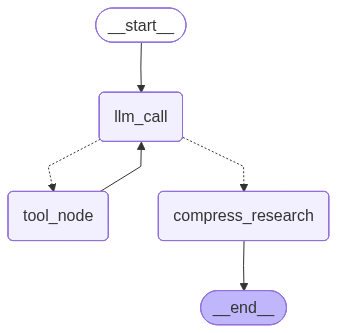

In [7]:
from IPython.display import Image, display
from deep_research_from_scratch.research_agent import researcher_agent

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [8]:
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to identify and evaluate the coffee shops in San Francisco that are considered the best based specifically  
on coffee quality. My research should focus on analyzing and comparing coffee shops within the San Francisco area, 
using coffee quality as the primary criterion. I am open regarding methods of assessing coffee quality (e.g.,      
expert reviews, customer ratings, specialty coffee certifications), and there are no constraints on ambiance,      
location, wifi, or food options unless they directly impact perceived coffee quality. Please prioritize primary    
sources such as the official websites of coffee shops, reputable third-party coffee review organizations (like     
Coffee Review or Specialty Coffee Association), and prominent review aggregators like Google or Yelp where direct  
customer feedback about coffee quality can be found. The study should result in a well-supported list or ranking of
the top coffee shops in San Francisco, emphasizing their coffee quality according to the latest available data as  
of July 2025."""

result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

TypeError: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"

In [9]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

NameError: name 'result' is not defined

# Evaluation

In [10]:
from langchain_core.messages import AIMessage, ToolMessage, HumanMessage

# Scenario 1: Agent should CONTINUE - has insufficient/irrelevant information + think_tool realizes more research needed
messages_should_continue = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll search for information about top coffee shops in San Francisco focusing on coffee quality.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "coffee shops San Francisco popular locations"
                },
                "id": "call_continue_search_001",
                "type": "tool_call"
            }
        ]
    ),
    # Tavily Search provides generic cafe information - NOT focused on coffee quality
    ToolMessage(
        content="Search results show popular San Francisco cafes: Blue Bottle Coffee has great wifi and ambiance, Philz Coffee is known for custom blends and friendly service, Café Reveille has multiple locations with good pastries and laptop-friendly spaces. Ritual Coffee offers cozy seating and is popular with students.",
        tool_call_id="call_continue_search_001",
    ),
    # Agent uses think_tool to reflect and realizes the search results are insufficient
    AIMessage(
        content="Let me use the think_tool to analyze these search results and determine next steps.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality."
                },
                "id": "call_continue_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response identifies the gap and need for more targeted research
    ToolMessage(
        content="Reflection recorded: Analysis of search results: The information I found focuses on general cafe features like wifi, ambiance, custom blends, and seating - but lacks specific coffee quality metrics. The user specifically asked for evaluation based on coffee quality, which would require expert reviews, professional ratings, specialty certifications, or quality-focused customer feedback. I need to search specifically for coffee quality assessments, Coffee Review scores, specialty coffee credentials, or expert evaluations of SF coffee shops. The current information is insufficient to answer the user's question about coffee quality.",
        tool_call_id="call_continue_think_001",
    )
]

# Scenario 2: Agent should STOP - has comprehensive coffee quality information + think_tool reflection
messages_should_stop = [
    HumanMessage(content="What are the top coffee shops in San Francisco based on coffee quality?"),
    AIMessage(
        content="I'll research San Francisco coffee shops specifically focusing on coffee quality assessments and expert reviews.",
        tool_calls=[
            {
                "name": "tavily_search",
                "args": {
                    "query": "best coffee quality San Francisco specialty coffee expert reviews Coffee Review ratings 2024"
                },
                "id": "call_stop_search_001", 
                "type": "tool_call"
            }
        ]
    ),
    # This ToolMessage provides COMPREHENSIVE coffee quality information - sufficient to answer the question
    ToolMessage(
        content="""Coffee quality research for San Francisco reveals top establishments based on expert reviews and specialty coffee credentials:

**Top Quality-Focused Coffee Shops:**
1. **Sightglass Coffee** - Coffee Review score 94/100, known for single-origin beans and precise roasting techniques. Featured in Bon Appétit's "Best Coffee in America" list for exceptional coffee quality.

2. **Saint Frank Coffee** - Ranked #3 coffee shop in America by The Daily Meal based on coffee quality. 4.3/5 Yelp rating with reviews specifically praising "exceptional bean quality" and "perfect extraction."

3. **Ritual Coffee Roasters** - Specialty Coffee Association member, direct trade relationships, consistently rated 4.4/5 on Google with reviews highlighting "superior coffee taste" and "expert barista skills."

4. **Blue Bottle Coffee** - Third-wave coffee pioneer, Coffee Review scores averaging 90+/100, known for rigorous quality control and fresh roasting practices.

5. **Four Barrel Coffee** - Local roaster with Coffee Review scores 88-92/100, praised by industry experts for "exceptional coffee quality" and innovative brewing methods.

**Quality Indicators Found:**
- Coffee Review professional scores (88-94/100 range)
- Specialty Coffee Association certifications
- Direct trade/single-origin sourcing
- Expert recognition from food publications
- Customer reviews specifically mentioning coffee taste and quality

This provides a comprehensive assessment of SF coffee shops based specifically on coffee quality rather than ambiance or service.""",
        tool_call_id="call_stop_search_001",
    ),
    # Agent now uses think_tool to reflect on the search results
    AIMessage(
        content="Let me reflect on the search results using the think_tool to assess whether I have sufficient information.",
        tool_calls=[
            {
                "name": "think_tool",
                "args": {
                    "reflection": "Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now."
                },
                "id": "call_think_001",
                "type": "tool_call"
            }
        ]
    ),
    # think_tool response confirming reflection was recorded
    ToolMessage(
        content="Reflection recorded: Analysis of search results: I found comprehensive coffee quality information for SF coffee shops including: 1) Professional Coffee Review scores (88-94/100), 2) Expert rankings from reputable publications, 3) Specialty Coffee Association certifications, 4) Specific quality indicators (single-origin, roasting techniques, extraction methods), 5) Five top-rated establishments with detailed quality assessments. This covers all aspects requested: expert reviews, customer ratings, specialty certifications. I have enough information to provide a well-supported ranking based specifically on coffee quality. No additional searches needed - I should provide my comprehensive answer now.",
        tool_call_id="call_think_001",
    )
]

In [12]:
import os
from langsmith import Client

langsmith_client = Client(api_key=os.getenv("LANGSMITH_API_KEY"))

dataset_name = 'deep_research_agent_termination'

if not langsmith_client.has_dataset(dataset_name = dataset_name):
    dataset = langsmith_client.create_dataset(dataset_name = dataset_name,
                                              description = "A dataset that evaluates whether a researcher can accurately decide to continue calling tools, or to stop.",
    )

    langsmith_client.create_examples(dataset_id = dataset.id,
                                     examples = [{
                                         'inputs' : {'researcher_messages': messages_should_continue},
                                         'outputs': {'next_Step': 'continue'}
                                         },
                                         {
                                             'inputs': {'researcher_messages': messages_should_stop},
                                             'outputs': {'next_Step': 'stop'}
                                         }])


In [13]:
import uuid

def evaluate_next_step(outputs: dict, reference_outputs:dict):
    tool_calls = outputs['researcher_messages'][-1].tool_calls
    made_tool_call = len(tool_calls)>0
    return{ 
        'key': 'correct_next_step',
        'score': made_tool_call == (reference_outputs['next_step'] == 'continue')
    }

def target_func(inputs: dict):
    config = { 'configurable': {'thread_id': uuid.uuid4()}}
    result = researcher_agent.nodes['llm_call'].invoke(inputs, config =config)
    return result

langsmith_client.evaluate(target_func, data = dataset_name, evaluators = [evaluate_next_step], experiment_prefix ='Researcher Iteration')

View the evaluation results for experiment: 'Researcher Iteration-1af3306d' at:
https://smith.langchain.com/o/8ebfc2f0-c8eb-4afc-ba88-aaa87bdd8958/datasets/003b5e05-ea49-4338-875a-0d19ea1ddd49/compare?selectedSessions=235bb87f-3fba-4335-95f5-b99c690890e8




0it [00:00, ?it/s]

Error running target function: "Could not resolve authentication method. Expected one of api_key, auth_token, or credentials to be set. Or for one of the `X-Api-Key` or `Authorization` headers to be explicitly omitted"
Traceback (most recent call last):
  File "e:\deep_research_from_scratch\.venv\Lib\site-packages\langsmith\evaluation\_runner.py", line 1939, in _forward
    fn(*args, langsmith_extra=langsmith_extra)
  File "e:\deep_research_from_scratch\.venv\Lib\site-packages\langsmith\run_helpers.py", line 777, in wrapper
    function_result = run_container["context"].run(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chara\AppData\Local\Temp\ipykernel_2984\3814629222.py", line 13, in target_func
    result = researcher_agent.nodes['llm_call'].invoke(inputs, config =config)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "e:\deep_research_from_scratch\.venv\Lib\site-packages\langgraph\pregel\_read.py", line 254, in invoke
 

<ExperimentResults Researcher Iteration-1af3306d>